In [ ]:
# Don't run this
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1                  2         2       

First 5 rows:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2                    

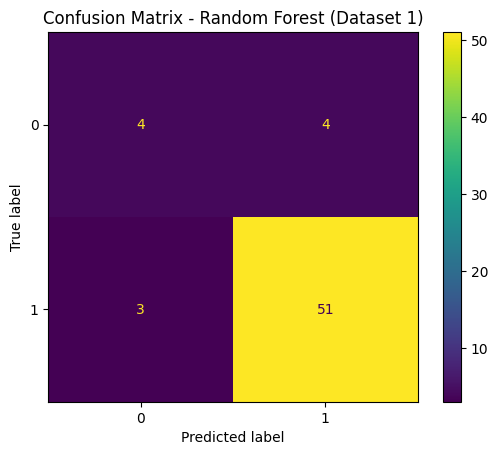

In [ ]:
# DATASET 1: survey lung cancer.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Load dataset
df1 = pd.read_csv("survey lung cancer.csv")

# Cleaning column names
df1.columns = df1.columns.str.strip()

# Preview
print("First 5 rows:")
print(df1.head())

print("\nColumn names:")
print(df1.columns.tolist())

print("\nDataset info:")
print(df1.info())

print("\nMissing values:")
print(df1.isnull().sum())

# Text to num
label_encoders = {}

for col in df1.columns:
    if df1[col].dtype == "object":
        le = LabelEncoder()
        df1[col] = le.fit_transform(df1[col].astype(str))
        label_encoders[col] = le

# Defining target and features
target_col = "LUNG_CANCER"
X1 = df1.drop(columns=[target_col])
y1 = df1[target_col]

# Checking class balance
print("\nClass distribution:")
print(y1.value_counts())

print("\nClass distribution (proportion):")
print(y1.value_counts(normalize=True))

# Train-test split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

# Random Forest model with imbalance handling
rf_model_1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train model
rf_model_1.fit(X1_train, y1_train)

# Predictions
y1_pred = rf_model_1.predict(X1_test)

# Metrics
accuracy_1 = accuracy_score(y1_test, y1_pred)
precision_1 = precision_score(y1_test, y1_pred, zero_division=0)
recall_1 = recall_score(y1_test, y1_pred, zero_division=0)
f1_1 = f1_score(y1_test, y1_pred, zero_division=0)

print("\n=== Random Forest Results: Dataset 1 ===")
print(f"Accuracy : {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall   : {recall_1:.4f}")
print(f"F1-score : {f1_1:.4f}")

# Confusion matrix
cm1 = confusion_matrix(y1_test, y1_pred)

print("\nConfusion Matrix:")
print(cm1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 1)")
plt.show()